In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=10, n_informative=3, n_classes=3, random_state=42)

In [5]:
print(X, y, sep='\n')

[[ 0.7715326  -1.47433614  2.19664605 ...  0.68174341  1.08996189
   0.96250289]
 [ 1.85838284 -3.68087983  0.22749588 ... -0.47417818  1.34113888
  -0.77177196]
 [-0.98724764  1.53916836  0.5859042  ... -0.32202815 -1.45103394
   1.32543211]
 ...
 [-1.227082    1.65602784  0.47263035 ... -0.8634936  -1.83932326
  -0.03120349]
 [ 1.28527572 -0.29715202 -0.67172079 ... -1.31544131  2.85446468
   1.3094441 ]
 [-0.75428048  0.88516075 -1.6728939  ... -2.0362205  -1.43989584
   0.04749347]]
[1 2 1 1 2 1 1 0 2 2 2 0 1 0 2 1 2 1 0 1 1 1 2 2 1 2 2 0 1 2 0 1 0 2 0 1 0
 0 2 0 1 0 2 1 2 0 2 0 2 0 0 0 2 1 1 1 1 2 0 0 2 1 0 0 1 2 0 2 2 1 0 1 1 1
 2 2 2 1 2 2 2 2 2 2 0 0 0 0 0 1 1 2 1 0 1 2 0 2 0 0 2 1 0 2 0 2 2 0 2 0 0
 0 0 2 1 2 1 0 2 0 0 2 1 0 2 1 0 0 2 2 0 0 0 2 1 2 2 0 2 0 1 2 1 2 1 1 2 0
 0 1 0 2 0 0 0 1 1 2 1 2 2 0 0 0 1 1 0 2 1 2 2 2 1 1 0 2 1 0 2 1 2 1 2 0 1
 1 0 2 2 2 2 0 2 0 0 0 0 2 1 2 1 1 0 2 2 2 2 2 2 2 1 1 1 2 2 0 2 2 2 0 2 0
 1 1 2 1 2 2 2 2 0 1 0 0 0 0 2 2 2 1 1 1 0 2 0 0 1 0 2 0 1

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.7, random_state=42)

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
logistic = OneVsRestClassifier(LogisticRegression(max_iter=1000))
logistic.fit(X_train, y_train)
y_pred = logistic.predict(X_test)


In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
score = accuracy_score(y_test, y_pred)
print(f"acc_score : {score}")
cm = confusion_matrix(y_test, y_pred)
print(f"confusion matrix : {cm}")
print(f"{classification_report(y_test, y_pred)}")

acc_score : 0.68
confusion matrix : [[79 16  8]
 [31 38 27]
 [ 3 11 87]]
              precision    recall  f1-score   support

           0       0.70      0.77      0.73       103
           1       0.58      0.40      0.47        96
           2       0.71      0.86      0.78       101

    accuracy                           0.68       300
   macro avg       0.67      0.67      0.66       300
weighted avg       0.67      0.68      0.66       300



In [9]:
model = LogisticRegression()
penalty = ['l1', 'l2', 'elasticnet']
c_values = [100, 10, 1, .1, 0.01]
solver = ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']

param_grid = [
    {
        'solver': ['lbfgs', 'newton-cg', 'sag'],
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 10, 100]
    },
    {
        'solver': ['saga'],
        'penalty': ['l1', 'l2', 'elasticnet'],
        'C': [0.01, 0.1, 1, 10, 100],
        'l1_ratio': [0.2, 0.5, 0.8]   # only used for elasticnet
    }
]

from sklearn.model_selection import RandomizedSearchCV
randomcv = RandomizedSearchCV(estimator=model, param_distributions=param_grid, cv = 5, scoring='accuracy')

In [10]:
randomcv.fit(X_train, y_train)

d:\Documents\data science Udemy\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Documents\data science Udemy\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1421: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
d:\Documents\data science Udemy\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=0.2. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
d:\Documents\data science Udemy\myenv\Lib\site-packages\sklearn\linear_model\_logistic

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['lbfgs', 'newton-cg', ...]}, {'C': [0.01, 0.1, ...], 'l1_ratio': [0.2, 0.5, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['saga']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluatio

In [11]:
randomcv.best_score_

np.float64(0.6528571428571428)

In [12]:
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold()

In [13]:
## GridSearchCV
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')

In [14]:
grid.fit(X_train, y_train)

d:\Documents\data science Udemy\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Documents\data science Udemy\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1421: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
d:\Documents\data science Udemy\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.2. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['lbfgs', 'newton-cg', ...]}, {'C': [0.01, 0.1, ...], 'l1_ratio': [0.2, 0.5, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['saga']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"error_score error_score: 'raise' or numeric, default=np.nanValue to assign to the score if an error occurs in estimator fitting.If set to 'raise', the error is raised. If a numeric value is given,FitFailedWarning is raised. This parameter does not affect the refitstep, which will always raise the error.",'raise'
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx

In [15]:
grid.best_score_

np.float64(0.6528571428571428)

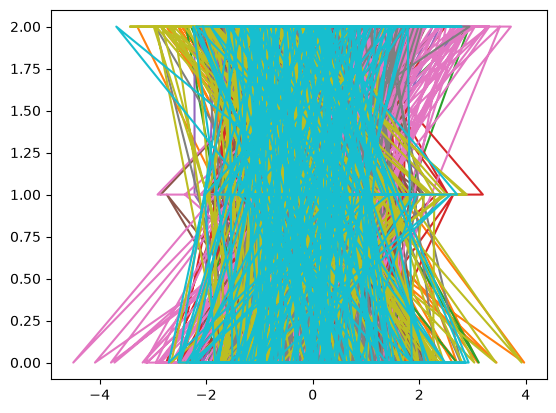

In [16]:
plt.plot(X_test, y_pred)


In [17]:
y_prob = logistic.predict_proba(X_test)

In [20]:
# plt.scatter(X_test, y_test, color='red')
# plt.scatter(X_test, y_prob, color='blue')
# plt.xlabel("Age")
# plt.ylabel("Probability")

In [21]:
y_prob

array([[9.22522618e-03, 2.44034837e-01, 7.46739937e-01],
       [4.89544732e-01, 2.45683892e-01, 2.64771376e-01],
       [3.54058728e-01, 5.90982894e-01, 5.49583777e-02],
       [3.61503652e-02, 1.82525799e-01, 7.81323836e-01],
       [4.01755652e-01, 3.69771801e-01, 2.28472547e-01],
       [3.83231093e-01, 5.21315790e-01, 9.54531172e-02],
       [2.80650254e-01, 2.18835528e-01, 5.00514218e-01],
       [6.86748730e-01, 3.10472372e-01, 2.77889720e-03],
       [5.72702266e-01, 4.24212176e-01, 3.08555794e-03],
       [2.69546511e-02, 1.49732219e-01, 8.23313130e-01],
       [7.81732426e-02, 2.40515273e-01, 6.81311484e-01],
       [1.25869742e-02, 1.72900197e-01, 8.14512828e-01],
       [4.99079983e-02, 1.76510922e-01, 7.73581080e-01],
       [3.95794074e-02, 3.56708621e-01, 6.03711972e-01],
       [2.01209577e-02, 2.98735180e-01, 6.81143862e-01],
       [7.35993162e-03, 2.18049789e-01, 7.74590279e-01],
       [2.71868855e-02, 2.81421225e-01, 6.91391890e-01],
       [2.36865580e-01, 4.86991

In [22]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(logistic, X_test, y_test)
plt.show()

ValueError: Expected 'estimator' to be a binary classifier. Got 3 classes instead.

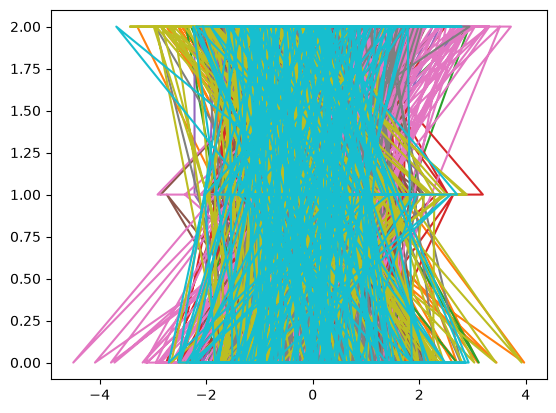

In [23]:
plt.plot(X_test, y_pred)

<Axes: xlabel='0', ylabel='1'>

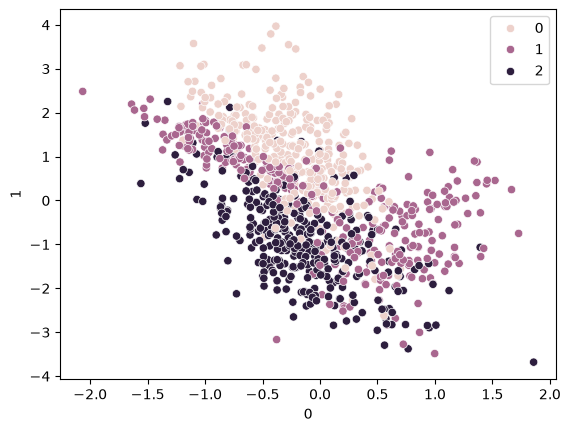

In [24]:
sns.scatterplot(x = pd.DataFrame(X)[0], y = pd.DataFrame(X)[1], hue = y)

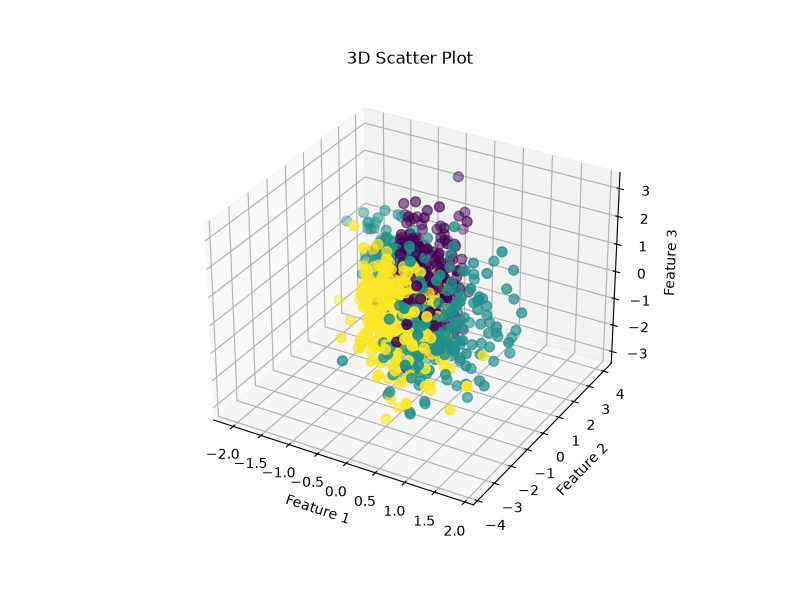

In [25]:
%matplotlib widget
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X[:, 0],
    X[:, 1],
    X[:, 2],
    c=y,
    cmap='viridis',
    s=50
)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Feature 3")
ax.set_title("3D Scatter Plot")

plt.show()

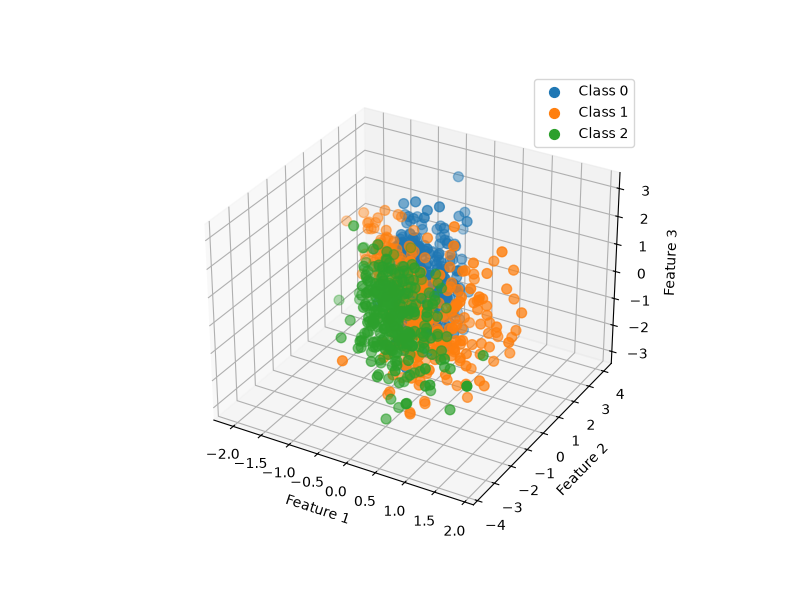

In [26]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

for cls in set(y):
    ax.scatter(
        X[y == cls, 0],
        X[y == cls, 1],
        X[y == cls, 2],
        label=f"Class {cls}",
        s=50
    )

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Feature 3")
ax.legend()

plt.show()